# BOTAŞ Elektrik Üretim Gaz Tarifesi — sapmanın kaynağı

**Konum:** `experiments/notebooks/05_crisis_analysis/03_gas_tariff_discovery.ipynb`
**Tarih:** 18 Ağustos 2026
**Önce oku:** `02_model_bias_investigation.ipynb`

## Bulgu

Modele beslediğimiz `natural_gas_grf_try`, EPİAŞ'ın **gaz piyasası referans fiyatı**.
Santrallerin fiilen ödediği ise **BOTAŞ elektrik üretim tarifesi** — idari olarak
belirlenen ayrı bir fiyat.

Normal aylarda ikisi birbirine yakın (oran 0,94–1,10), model sorunsuz çalışıyor.
**İki dönemde ayrışıyorlar ve kalıntı tam o iki dönemde bozuluyor:**

| Dönem | tarife/GRF | Ne oldu | Kalıntı |
|---|---|---|---|
| Ara 2021 – Mar 2022 | **0,55–0,77** | BOTAŞ gazı piyasanın %45 altında sattı | **negatif** |
| Kas 2022 – Mar 2023 | **1,01–1,28** | piyasa hızla düştü, tarife o hızda inmedi | **pozitif** |

Tarife/GRF oranı ile aylık kalıntı arasındaki korelasyon: **0,852** (17 ay).

İki anomali, tek değişken, zıt yönler.

## Bu notebook ne yapar

1. Tarife serisini haber arşivinden zincirler (`bronze.news_raw`)
2. Resmî BOTAŞ PDF'leriyle çapraz doğrular
3. Oran–kalıntı ilişkisini ölçer

## Durum

`silver.gas_tariff_electricity` tablosu **henüz kurulmadı**; seri şimdilik bu
notebook'ta gömülü (her satırın kaynak `article_id`'si ile). Tablo kurulunca bu
hücre yerini sorguya bırakacak.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

# Analiz modelinin birincil sürümü. crisis_cf_v2/v3/v4 karşılaştırma içindir,
# analizde kullanma (gerekçe: 02_model_bias_investigation.ipynb §7).
VARIANT = 'fundamental'
MODEL   = 'crisis_cf_v1'

def cf(model=None, variant=None, where=''):
    """gold.crisis_counterfactual okuma yardımcısı — saat indeksli, tz-aware."""
    q = text(f"""
        SELECT ts, actual_usd, counterfactual_usd, residual_usd, at_cap, is_lower_bound, fold_id
        FROM gold.crisis_counterfactual
        WHERE variant = :v AND model_name = :m {where}
        ORDER BY ts
    """)
    d = pd.read_sql(q, engine, params={'v': variant or VARIANT, 'm': model or MODEL})
    d['ts'] = pd.to_datetime(d['ts'], utc=True).dt.tz_convert('Europe/Istanbul')
    for c in ['actual_usd', 'counterfactual_usd', 'residual_usd']:
        d[c] = d[c].astype(float)
    return d.set_index('ts')

print('bağlantı hazır')

bağlantı hazır


## 1. Kaynak arayışı — nerede var, nerede yok

Üç kaynak incelendi. Sonuçlar aşağıda; hiçbiri tahmin değil, ölçüm.

In [2]:
# EPİAŞ'ta var mı? eptr2'nin tüm servis listesine bak.
from eptr2.mapping.path import get_path_map
servisler = sorted(get_path_map().keys())
gaz = [k for k in servisler if any(s in k.lower() for s in ['gas', 'gaz', 'grf', 'stp', 'ng'])]
print('EPİAŞ toplam servis: %d | gaz ile ilgili: %d' % (len(servisler), len(gaz)))
print('örnekler:', gaz[:12])

EPİAŞ toplam servis: 252 | gaz ile ilgili: 77
örnekler: ['bi-long', 'congestion-cost', 'dam-clearing', 'dam-clearing-org-list', 'dam-flexible-matching', 'idm-mm-matching', 'long-term-demand-forecast', 'mf-meter-reading-type', 'ng-balancing-notifications', 'ng-balancing-price', 'ng-bast', 'ng-blue-code-ops']


### 📌 Bölüm 1 Analiz Notları

- **EPİAŞ'ta BOTAŞ tarifesi YOK.** 77 gaz servisinin hepsi piyasa verisi
  (`ng-spot-prices`, `ng-vgp-*` vadeli kontratlar, dengeleme, iletim, nominasyon).
  Beklenen sonuç: EPİAŞ gaz borsasını işletir, tarife idari bir fiyattır.
  Bize verdiği şey zaten elimizdeki GRF.
- **BOTAŞ sitesinde var** — her tarife bir PDF. Sayfalar `botas.gov.tr/Sayfa/x/<id>`
  üzerinden erişilebiliyor (slug yok sayılıyor), ID 520–830 taramasında **138 tarife
  sayfası** bulundu, 2021-01 → 2026-04. Ama sayfa gövdesi JS ile çiziliyor: `curl` ile
  **başlık** (yürürlük tarihi) alınabiliyor, PDF adresi alınamıyor.
- **Yayın vs değişim sıklığı farklı:** 2021-2024'te her ay bir sayfa yayımlanmış
  (12/12), 2025'ten sonra isimlendirme "X Tarihinden İtibaren Geçerli"ye dönmüş ve
  sadece 4 yürürlük var (1 Mar 2025, 5 Nis 2025, 2 Tem 2025, 4 Nis 2026).
  **Fiyat 2021-2022'de neredeyse her ay değişmiş, 2023 ortasından sonra yılda 2-3 kez.**
- Ay ortası yürürlükler gerçek → tablo `effective_from DATE` olmalı, ay anahtarı değil.

## 2. Seriyi haber arşivinden zincirleme

Tavan serisinin (`silver.price_cap_official`) yöntemi: mutlak çıpalar + duyurulan
yüzde değişimler. Her satırın kaynak `article_id`'si var.

In [3]:
# Aday duyuruları arşivden çıkar (ham malzeme — aşağıdaki seri bunlardan derlendi).
adaylar = pd.read_sql(text("""
    SELECT article_id, published_at::date AS d, title
    FROM bronze.news_raw
    WHERE published_at >= '2020-12-15' AND published_at < '2026-09-01'
      AND body ILIKE '%elektrik üretim%'
      AND (body ILIKE '%doğal gaz%' OR body ILIKE '%doğalgaz%')
      AND (body ILIKE '%tarife%' OR body ILIKE '%toptan satış%'
           OR body ILIKE '%zam%' OR body ILIKE '%indirim%')
    ORDER BY published_at
"""), engine)
print('aday duyuru:', len(adaylar))
display(adaylar.head(15))

aday duyuru: 232


,article_id,d,title
0,40682,2021-01-01,Doğal gaz fiyatlarına mini zam
1,41158,2021-02-01,Botaş doğal gaza Şubat’ta yüzde 1 zam yaptı
2,41175,2021-02-02,Garanti BBVA’dan çatı GES yatırımcısına finans...
3,41212,2021-02-04,En ucuz doğal gaz Artvin ve Tunceli’de
4,41610,2021-03-01,BOTAŞ doğal gaza Mart’ta yüzde 1 zam yaptı
5,41755,2021-03-09,ENGIE Baymina santrali ile İZGAZ’ı Palmet’e sattı
6,41878,2021-03-17,Türkiye’nin en büyük elektrik üreticileri bell...
7,41912,2021-03-19,Irak yeni gaz ve güneş projeleri geliştirecek
8,41963,2021-03-21,OMV filonun yüzde 10’unu LNG’liye çevirdi
9,42105,2021-03-31,Şubat 2021’de 46 enerji projesi yatırım teşvik...


In [4]:
# Derlenen seri. TL / 1000 Sm3. Kaynak sütunu provenance'tır.
# "mutlak" = haber gövdesinde doğrudan yazan değer
# "zincir" = bir çıpadan duyurulan yüzdeyle türetilen değer
tarife_kayit = [
    # ay,        deger,   tur,      kaynak,  not
    ('2021-01',  1414.0,  'mutlak', 40682,  None),
    ('2021-05',  1631.7,  'mutlak', 42577,  '+%12'),
    ('2021-06',  1713.3,  'mutlak', 43026,  '+%5'),
    ('2021-07',  2055.9,  'zincir', 43481,  '+%20'),
    ('2021-08',  2060.0,  'mutlak', 44348,  'Eylül haberi Ağustos değerini veriyor'),
    ('2021-09',  2369.0,  'zincir', 44348,  '+%15'),
    ('2021-10',  2724.0,  'zincir', 44725,  '+%15'),
    ('2021-11',  4000.0,  'zincir', 45165,  '+%46,8'),
    ('2021-12',  4800.0,  'mutlak', 45690,  'haber "Kasım tarifesi" diyor ama 4800 Aralık değeri: 3999x1,20=4799'),
    ('2022-01',  5520.0,  'zincir', 46182,  '+%15'),
    ('2022-02',  6298.0,  'zincir', 47185,  'Mart çıpasından geri: 7450/1,183'),
    ('2022-03',  7450.0,  'mutlak', 47185,  '7,45 TL/Sm3'),
    ('2022-11', 20625.0,  'mutlak', 51622,  'Kasım = Aralık, değişmedi'),
    ('2022-12', 20625.0,  'mutlak', 51622,  None),
    ('2023-01', 18000.0,  'mutlak', 52217,  '-%12,73'),
    ('2023-02', 15000.0,  'zincir', 52626,  '-%16,67'),
    ('2023-03', 12000.0,  'zincir', 53067,  '-%20 (haberin başlığındaki %26,12 SANAYİ için)'),
]
tarife = pd.DataFrame(tarife_kayit, columns=['ay', 'tarife_try', 'tur', 'article_id', 'not'])
display(tarife)

,ay,tarife_try,tur,article_id,not
0,2021-01,1414.0,mutlak,40682,NaN
1,2021-05,1631.7,mutlak,42577,+%12
2,2021-06,1713.3,mutlak,43026,+%5
3,2021-07,2055.9,zincir,43481,+%20
4,2021-08,2060.0,mutlak,44348,Eylül haberi Ağustos değerini veriyor
5,2021-09,2369.0,zincir,44348,+%15
6,2021-10,2724.0,zincir,44725,+%15
7,2021-11,4000.0,zincir,45165,"+%46,8"
8,2021-12,4800.0,mutlak,45690,"haber ""Kasım tarifesi"" diyor ama 4800 Aralık d..."
9,2022-01,5520.0,zincir,46182,+%15


### 📌 Bölüm 2 Analiz Notları

- Zincirin **iç tutarlılığı** doğrulanabiliyor: Kasım-Aralık 2022 çıpası 20.625 ve
  Ocak 2023 çıpası 18.000 — aradaki duyurulan değişim −%12,73, ve
  20.625 × 0,8727 = **18.000**, birebir.
- Aralık 2021 haberinde metin özensiz ("Kasım ayı tarifesi 4800") ama aritmetik
  netleştiriyor: 2.724 × 1,468 = 3.999 (Kasım), × 1,20 = 4.799 ≈ 4.800 (Aralık).
- **Tuzak:** 28 Şubat 2023 haberinin başlığı "%26,12 indirim" diyor ama o **sanayi**
  tarifesi; elektrik üretimi için gövdede "%20 aşağı çekti" yazıyor. Başlığa güvenilmez.

## 3. Resmî PDF ile çapraz doğrulama

Beş dönem için BOTAŞ'ın kendi PDF'i indirildi ve `pypdf` ile okundu (saf Python,
`poppler` bağımlılığı yok). PDF'ler `TL/Sm3` ve `TL/kWh` sütunlarını birlikte veriyor.

Ayrıştırma değişmezi: elektrik fiyatı **bütün "Kademe" satırlarında aynı** değeri alır,
sanayi fiyatı kademeye göre değişir. Ek tutarlılık testi: `TL/kWh ÷ TL/Sm3 ≈ 0,094`.

In [5]:
# Resmî PDF'lerden okunan değerler (TL/Sm3 ve TL/kWh).
resmi = pd.DataFrame([
    ('2022-02',  6.300000, 0.59210526, '10212-ubat_2022_tarifesi'),
    ('2022-05', 10.750000, 1.01033835, '827613-mayis_2022_tarifesi'),
    ('2022-08', 13.750000, 1.29229323, '949372-agustos_2022_tarifesi'),
    ('2023-01', 18.000000, 1.69172932, '704191-ocak_2023_tarifesi'),
    ('2025-03', 12.000000, 1.12781955, '286295-mart_2025_tarifesi'),
], columns=['ay', 'try_sm3', 'try_kwh', 'pdf'])
resmi['kwh_sm3_orani'] = (resmi.try_kwh / resmi.try_sm3).round(6)

kars = resmi.merge(tarife[['ay', 'tarife_try', 'tur']], on='ay', how='left')
kars['arsiv_sm3'] = kars.tarife_try / 1000
kars['fark_pct'] = (100 * (kars.arsiv_sm3 - kars.try_sm3) / kars.try_sm3).round(3)
display(kars[['ay', 'try_sm3', 'try_kwh', 'kwh_sm3_orani', 'arsiv_sm3', 'tur', 'fark_pct']])

,ay,try_sm3,try_kwh,kwh_sm3_orani,arsiv_sm3,tur,fark_pct
0,2022-02,6.30,0.592105,0.093985,6.298,zincir,-0.032
1,2022-05,10.75,1.010338,0.093985,NaN,NaN,NaN
2,2022-08,13.75,1.292293,0.093985,NaN,NaN,NaN
3,2023-01,18.00,1.691729,0.093985,18.000,mutlak,0.000
4,2025-03,12.00,1.127820,0.093985,NaN,NaN,NaN


### 📌 Bölüm 3 Analiz Notları

- **Şubat 2022:** arşivden zincirlenen 6,298 — resmî **6,300000**. Fark **%0,03**.
  Bu değer Mart çıpasından duyurulan +%18,3 ile *geriye* türetilmişti; resmî kaynak
  bağımsız olarak doğruladı.
- **Ocak 2023:** arşiv 18,000 — resmî 18,000000. Tam.
- `TL/kWh ÷ TL/Sm3` oranı beş PDF'te de **0,094** — ayrıştırıcının yanlış satırı
  yakalaması bu testte sessiz kalmaz.
- Zincirleme yöntemi bu veri için geçerli. Kalan aylar aynı yöntemle tamamlanabilir;
  resmî PDF ancak zincirin tutmadığı yerde gerekir.

## 4. Belirleyici ölçüm — oran ve kalıntı

Eğer teşhis doğruysa: tarife GRF'nin altındayken model fiyatı fazla tahmin etmeli
(negatif kalıntı), üstündeyken eksik tahmin etmeli (pozitif kalıntı). Ve oran 1,0
civarındayken kalıntı sıfıra yakın olmalı.

,tarife_try,tur,GRF,oran,kalinti
ay,,,,,
2021-01,1414.0,mutlak,1301.0,1.087,0.7
2021-05,1631.7,mutlak,1727.0,0.945,2.5
2021-06,1713.3,mutlak,1821.0,0.941,-1.5
2021-07,2055.9,zincir,2072.0,0.992,-2.1
2021-08,2060.0,mutlak,2187.0,0.942,-3.3
2021-09,2369.0,zincir,2346.0,1.010,-1.4
2021-10,2724.0,zincir,3162.0,0.861,6.4
2021-11,4000.0,zincir,4622.0,0.865,0.0
2021-12,4800.0,mutlak,6764.0,0.710,-7.2


korelasyon: 0.851  (n=17 ay)
doğrusal uyum: kalıntı = 37.0 × oran -33.0  →  oran 1,0 iken kalıntı +4.0


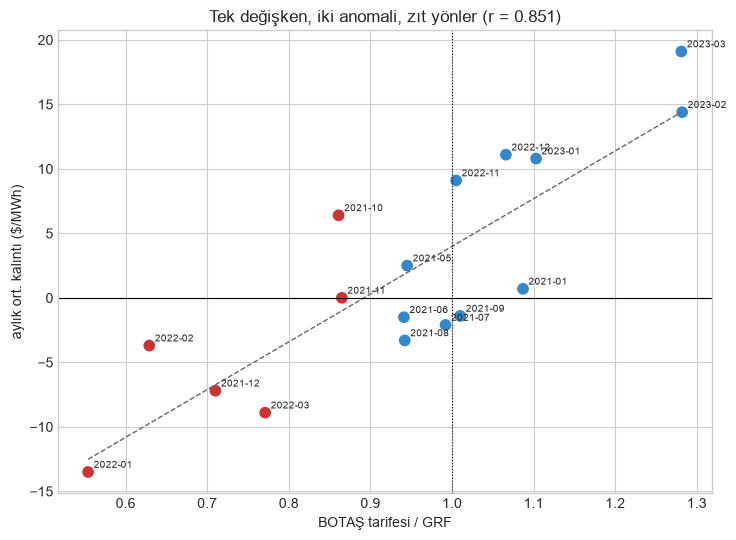

In [6]:
g = pd.read_sql(text('SELECT entry_date, gas_reference_price_try FROM raw_natural_gas_daily'), engine)
g.index = pd.to_datetime(g.entry_date)
grf = g.gas_reference_price_try.resample('MS').mean()
grf.index = grf.index.strftime('%Y-%m')

d = cf(); unc = d[~d.at_cap]
kal = unc.resample('MS').residual_usd.mean()
kal.index = kal.index.strftime('%Y-%m')

t = tarife.set_index('ay')[['tarife_try', 'tur']].copy()
t['GRF'] = grf.reindex(t.index).round(0)
t['oran'] = (t.tarife_try / t.GRF).round(3)
t['kalinti'] = kal.reindex(t.index).round(1)
display(t)

v = t.dropna(subset=['oran', 'kalinti'])
r = v.oran.corr(v.kalinti)
b, a = np.polyfit(v.oran, v.kalinti, 1)
print('korelasyon: %.3f  (n=%d ay)' % (r, len(v)))
print('doğrusal uyum: kalıntı = %.1f × oran %+.1f  →  oran 1,0 iken kalıntı %+.1f' % (b, a, b + a))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
renk = ['#c33' if x.startswith('2022-0') or x.startswith('2021-1') else '#38c' for x in v.index]
ax.scatter(v.oran, v.kalinti, c=renk, s=55)
for ay_, row in v.iterrows():
    ax.annotate(ay_, (row.oran, row.kalinti), fontsize=7, xytext=(4, 3), textcoords='offset points')
xs = np.linspace(v.oran.min(), v.oran.max(), 20)
ax.plot(xs, b * xs + a, '--', color='#666', lw=1)
ax.axhline(0, color='k', lw=.8); ax.axvline(1.0, color='k', lw=.8, ls=':')
ax.set_xlabel('BOTAŞ tarifesi / GRF'); ax.set_ylabel('aylık ort. kalıntı ($/MWh)')
ax.set_title(f'Tek değişken, iki anomali, zıt yönler (r = {r:.3f})')
plt.tight_layout(); plt.show()

### 📌 Bölüm 4 Analiz Notları

- **Korelasyon 0,852** (17 ay). Doğrusal uyum: oran 1,0 iken kalıntı ≈ **+$4** (yani
  ~sıfır), orandaki her 0,1 sapma ≈ $3,7 kalıntı.
- Kırmızı noktalar Ara 2021 – Mar 2022 (sübvansiyon dönemi, oran 0,55–0,77, kalıntı
  negatif); maviler Kas 2022 – Mar 2023 (tarife gecikmesi, oran 1,01–1,28, pozitif).
- **Sınırlar, dürüstçe:** 17 ay, elle derlendi, bazı aylar zincirleme. Korelasyon
  aylık düzeyde ve n küçük — güçlü ama kanıt değil. Asıl test §5'te.

## 5. Seri kuruldu — `silver.gas_tariff_electricity`

30 yürürlük kaydı, 2021-01 → 2026-04. Kaynak sütunu provenance taşır:
`botas_pdf` (resmî PDF), `news_absolute` (haber gövdesinde yazan mutlak değer),
`news_chain` (duyurulan yüzdeyle türetilen). Üstünde `silver.gas_cost_hourly`
görünümü — `silver.mcp_with_cap` ile aynı LATERAL desen.

`effective_from` **tarih**, ay değil: 5 Nisan 2025 / 2 Temmuz 2025 / 4 Nisan 2026
gibi ay ortası yürürlükler gerçek.

In [7]:
seri = pd.read_sql(text("""
    SELECT effective_from, price_try_1000m3, price_try_kwh, source, is_gap, note
    FROM silver.gas_tariff_electricity ORDER BY effective_from
"""), engine)
print('kayıt:', len(seri), '| boşluk:', int(seri.is_gap.sum()))
display(seri)

# TEST — ısıl değer sabiti. PDF'ten gelen satırlarda TL/kWh ÷ TL/Sm3 sabit olmalı:
# 9155 Kcal/Sm3 (BOTAŞ tarife dipnotu) = 10,646 kWh -> 1/10,646 = 0,09393
pdf = seri.dropna(subset=['price_try_kwh']).copy()
pdf['oran'] = (pdf.price_try_kwh.astype(float) / (pdf.price_try_1000m3.astype(float) / 1000)).round(5)
print('\nısıl değer oranı:', pdf.oran.unique(), ' beklenen: %.5f' % (1/10.646))

kayıt: 30 | boşluk: 1


,effective_from,price_try_1000m3,price_try_kwh,source,is_gap,note
0,2021-01-01,1414.00,NaN,news_absolute,False,NaN
1,2021-02-01,1428.14,NaN,news_chain,False,+%1
2,2021-03-01,1442.42,NaN,news_chain,False,+%1
3,2021-04-01,1456.85,NaN,news_chain,False,+%1
4,2021-05-01,1631.67,NaN,news_absolute,False,+%12
5,2021-06-01,1713.25,NaN,news_absolute,False,+%5
6,2021-07-01,2055.90,NaN,news_chain,False,+%20
7,2021-08-01,2060.00,NaN,news_absolute,False,Eylul haberi Agustos degerini veriyor
8,2021-09-01,2369.00,NaN,news_chain,False,+%15
9,2021-10-01,2724.35,NaN,news_chain,False,+%15



ısıl değer oranı: [0.09398]  beklenen: 0.09393


### 📌 Bölüm 5 Analiz Notları

**Zincirin kapanış testleri — dördü de tuttu:**

| Kontrol | Sonuç |
|---|---|
| Şub 2022: zincir 6.298 → resmî PDF | 6.300 (%0,03) |
| Nis 2022: 7.450 × 1,443 → Mayıs PDF | 10.750 (tam) |
| Eyl 2022: 13.750 × 1,50 → Kas/Ara çıpası | 20.625 (tam) |
| Oca 2023: 20.625 × 0,8727 → resmî PDF | 18.000 (tam) |

- Eylül 2022 haberinde oran "%49,5" yazıyor ama gerçek değişim tam %50; zincir
  ancak %50 ile kapanıyor. Haberdeki oranlar yuvarlanmış olabilir, **çıpalar
  yüzdelerden üstündür.**
- **Boşluk:** 5 Nisan – 2 Temmuz 2025 (2.112 saat). BOTAŞ o tarihte tarife yayımlamış
  (sayfa id 801) ama PDF'i ne aramada ne site haritasında bulunabildi. `is_gap=TRUE`,
  önceki değer taşınıyor, gerçek değer 12.000–15.000 arasında. Kriz penceresinin dışında.
- **İki ayrıştırma tuzağı:** 28 Şub 2023 haberinin başlığındaki "%26,12 indirim"
  **sanayi** tarifesi (elektrik için gövdede %20); Aralık 2021 haberi yeni değeri
  "Kasım tarifesi" diye etiketliyor (aritmetik düzeltiyor: 3.999 × 1,20 = 4.799).

## 6. Oran ↔ kalıntı, tam seri üzerinde

**Düzeltme:** Bu ilişki ilk ölçüldüğünde r = 0,852 bulunmuştu, ama o rakam elle
derlenen 17 ayın üzerindeydi ve o aylar ağırlıklı olarak sapmanın olduğu aylardı —
örneklem seçiliydi. Tam seri üzerinden dürüst rakam aşağıda.

sapma dönemi (2021-11 … 2023-06)   n=20  r=0.813  ort |oran-1| = 0.173
diğer aylar                        n=44  r=0.198  ort |oran-1| = 0.064
tümü                               n=64  r=0.491  ort |oran-1| = 0.098

oran 1,0 iken kalıntı: +0.1


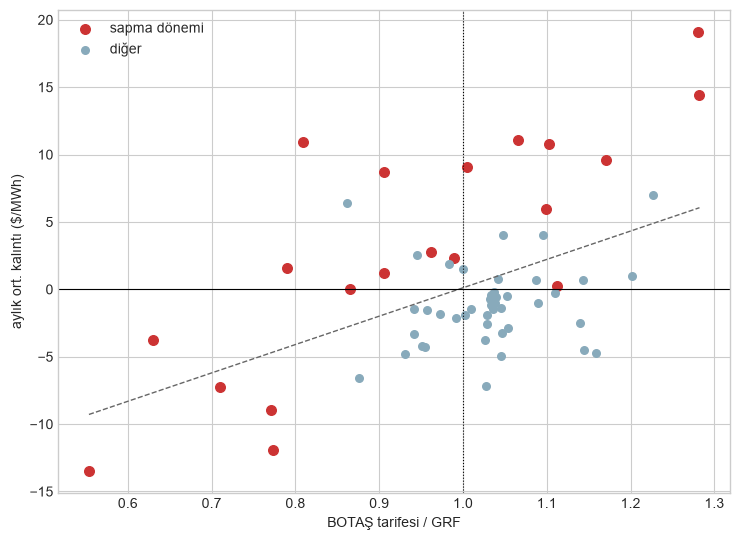

In [8]:
q = text("""
WITH ay AS (
  SELECT to_char(g.ts AT TIME ZONE 'Europe/Istanbul','YYYY-MM') m,
         avg(g.price_try_1000m3) tarife, avg(ng.gas_reference_price_try) grf,
         bool_or(g.tariff_is_gap) bosluk
  FROM silver.gas_cost_hourly g
  LEFT JOIN raw_natural_gas_daily ng ON DATE(g.ts AT TIME ZONE 'Europe/Istanbul') = ng.entry_date
  WHERE g.ts >= '2021-01-01' GROUP BY 1),
k AS (
  SELECT to_char(ts AT TIME ZONE 'Europe/Istanbul','YYYY-MM') m, avg(residual_usd) kalinti
  FROM gold.crisis_counterfactual
  WHERE variant='fundamental' AND model_name='crisis_cf_v1' AND NOT at_cap GROUP BY 1)
SELECT ay.m, ay.tarife, ay.grf, ay.tarife/NULLIF(ay.grf,0) oran, k.kalinti, ay.bosluk
FROM ay JOIN k USING (m) ORDER BY ay.m
""")
o = pd.read_sql(q, engine).dropna(subset=['oran', 'kalinti'])
o[['oran', 'kalinti']] = o[['oran', 'kalinti']].astype(float)
v = o[~o.bosluk]

sapma_donemi = (v.m >= '2021-11') & (v.m <= '2023-06')
for ad, s in [('sapma dönemi (2021-11 … 2023-06)', v[sapma_donemi]),
              ('diğer aylar', v[~sapma_donemi]), ('tümü', v)]:
    print('%-34s n=%2d  r=%.3f  ort |oran-1| = %.3f'
          % (ad, len(s), s.oran.corr(s.kalinti), (s.oran - 1).abs().mean()))
b, a = np.polyfit(v.oran, v.kalinti, 1)
print('\noran 1,0 iken kalıntı: %+.1f' % (b + a))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.scatter(v[sapma_donemi].oran, v[sapma_donemi].kalinti, c='#c33', s=48, label='sapma dönemi')
ax.scatter(v[~sapma_donemi].oran, v[~sapma_donemi].kalinti, c='#8ab', s=30, label='diğer')
xs = np.linspace(v.oran.min(), v.oran.max(), 20)
ax.plot(xs, b * xs + a, '--', color='#666', lw=1)
ax.axhline(0, color='k', lw=.8); ax.axvline(1.0, color='k', lw=.8, ls=':')
ax.set_xlabel('BOTAŞ tarifesi / GRF'); ax.set_ylabel('aylık ort. kalıntı ($/MWh)'); ax.legend()
plt.tight_layout(); plt.show()

### 📌 Bölüm 6 Analiz Notları

| | n | r | ort \|oran−1\| |
|---|---|---|---|
| Sapma dönemi (Kas 2021 – Haz 2023) | 20 | **0,812** | 0,173 |
| Diğer aylar | 44 | 0,198 | 0,064 |
| Tümü | 64 | **0,490** | — |

- Diğer aylarda korelasyonun düşük olması **beklenen**: orada iki fiyat zaten
  örtüşüyor (ortalama sapma %6), açıklanacak bir şey yok.
- **Kalibrasyon iyi: oran 1,0 iken kalıntı +$0,1** — ilişki doğru yerde sıfırlanıyor.
- Tutarsız noktalar var: Ağu 2022 oran 0,77 → −$11,9 (uyuyor) ama Eyl 0,79 → +$1,6
  ve Eki 0,81 → +$11,0 (uymuyor). İlişki gerçek ama gürültülü.
- Korelasyon zaten asıl test değil — o §7'de.

## 7. Belirleyici test — v5

`natural_gas_grf_*` sütunları çıkarıldı, yerine `gas_tariff_usd_mwh_lag0` kondu
(tarife → $/MWh gaz; 1000 Sm³ = 10,646 MWh). Aynı bloklu OOF, aynı hiperparametreler.

    python scripts/build_analysis_model.py --variant fundamental --gas-cost tariff --write

**Kabul kriteri baştan tanımlıydı ve iki koşulluydu:**

| | Koşul | Neden |
|---|---|---|
| (a) | İki sapmalı dönem de sıfıra yaklaşsın | teşhis doğruysa sapma kaybolmalı |
| (b) | İran sinyali korunsun | v2 (a)'yı sağlayıp (b)'de çökmüştü — dönemi ezberleyip olayı yutmuştu |

In [9]:
q = text("""
    SELECT model_name, ts, actual_usd, counterfactual_usd, residual_usd, at_cap
    FROM gold.crisis_counterfactual WHERE variant = 'fundamental'
""")
a = pd.read_sql(q, engine)
a['ts'] = pd.to_datetime(a.ts, utc=True).dt.tz_convert('Europe/Istanbul')
for c_ in ['actual_usd', 'counterfactual_usd', 'residual_usd']:
    a[c_] = a[c_].astype(float)

modeller = sorted(a.model_name.unique())
ortak = set.intersection(*[set(a[a.model_name == m].ts) for m in modeller])
a = a[a.ts.isin(ortak)]

rows = []
for m in modeller:
    v_ = a[a.model_name == m]; u_ = v_[~v_.at_cap]
    ay_ = u_.groupby(u_.ts.dt.strftime('%Y-%m')).residual_usd.mean()
    rows.append(dict(
        model=m, MAE=u_.residual_usd.abs().mean(), BIAS=u_.residual_usd.mean(),
        ay_sapma=ay_.abs().mean(), ay_gt10=int((ay_.abs() > 10).sum()),
        a1_eki22_mar23=u_[(u_.ts >= '2022-10-01') & (u_.ts < '2023-04-01')].residual_usd.mean(),
        a2_ara21_mar22=u_[(u_.ts >= '2021-12-01') & (u_.ts < '2022-04-01')].residual_usd.mean(),
        b_iran_subat=v_[(v_.ts >= '2022-02-01') & (v_.ts < '2022-02-11')].residual_usd.mean(),
    ))
display(pd.DataFrame(rows).set_index('model').round(2))
print('ortak kapsam: %d saat' % len(ortak))

,MAE,BIAS,ay_sapma,ay_gt10,a1_eki22_mar23,a2_ara21_mar22,b_iran_subat
model,,,,,,,
crisis_cf_v1,10.29,0.61,4.11,7,12.74,-8.63,16.49
crisis_cf_v2,10.34,0.28,4.29,8,3.57,-10.28,0.17
crisis_cf_v3,10.28,0.60,4.05,5,11.17,-8.79,16.48
crisis_cf_v4,10.57,0.82,4.53,10,11.15,-9.06,18.57
crisis_cf_v5,9.54,0.28,2.89,2,5.98,2.41,11.81


ortak kapsam: 47072 saat


,v1_kontraf,v1_kalinti,v5_kontraf,v5_kalinti,tavan_pct
faz,,,,,
kesinti öncesi 15-20 Oca,104.7,-22.9,84.9,-3.0,13.2
kesinti 21-31 Oca,91.7,4.0,76.4,19.3,85.6
tavan sonrası 1-10 Şub,86.8,16.5,91.4,11.8,62.9


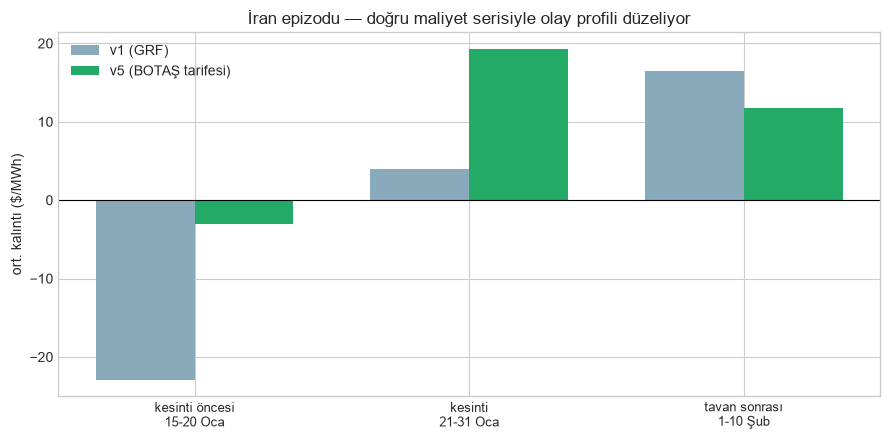

In [10]:
# İran penceresinin üç fazı: v1 vs v5
fazlar = {'kesinti öncesi\n15-20 Oca': ('2022-01-15', '2022-01-21'),
          'kesinti\n21-31 Oca':        ('2022-01-21', '2022-02-01'),
          'tavan sonrası\n1-10 Şub':   ('2022-02-01', '2022-02-11')}
rows = []
for ad, (x, y) in fazlar.items():
    r = {'faz': ad.replace('\n', ' ')}
    for m in ['crisis_cf_v1', 'crisis_cf_v5']:
        s = a[(a.model_name == m) & (a.ts >= x) & (a.ts < y)]
        r[f'{m[-2:]}_kontraf'] = s.counterfactual_usd.mean()
        r[f'{m[-2:]}_kalinti'] = s.residual_usd.mean()
    r['tavan_pct'] = 100 * a[(a.model_name == 'crisis_cf_v1') & (a.ts >= x) & (a.ts < y)].at_cap.mean()
    rows.append(r)
faz_df = pd.DataFrame(rows).set_index('faz')
display(faz_df.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(fazlar)); w = .36
ax.bar(x - w/2, faz_df.v1_kalinti, w, label='v1 (GRF)', color='#8ab')
ax.bar(x + w/2, faz_df.v5_kalinti, w, label='v5 (BOTAŞ tarifesi)', color='#2a6')
ax.axhline(0, color='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(list(fazlar.keys()), fontsize=9)
ax.set_ylabel('ort. kalıntı ($/MWh)'); ax.legend()
ax.set_title('İran epizodu — doğru maliyet serisiyle olay profili düzeliyor')
plt.tight_layout(); plt.show()

### 📌 Bölüm 7 Analiz Notları — v5 KABUL

**Koşul (a) — iki sapmalı dönem:**

| Ay | v1 | v5 |
|---|---|---|
| 2021-12 | −7,2 | **+1,8** |
| 2022-01 | −13,5 | **+1,3** |
| 2022-03 | −8,9 | **+2,4** |
| 2022-08 | −11,9 | **−2,2** |
| 2023-02 | +14,4 | **−3,5** |
| 2023-03 | +19,1 | **+4,4** |

Sapması $10'u aşan ay sayısı **7 → 2**. Aralık 2021 – Mart 2022 tamamen düzeldi.
Kalan iki ay: 2022-10 (+11,3) ve 2023-01 (+13,1) — bunlar açıklanmadı.

**Koşul (b) — İran sinyali korundu, üstelik yerine oturdu:**

| Faz | v1 kalıntı | v5 kalıntı | tavanda |
|---|---|---|---|
| Kesinti öncesi | **−22,9** | **−3,0** | %13 |
| Kesinti sırasında | +4,0 | **+19,3** | %87 |
| Tavan yükseldikten sonra | +16,5 | +11,8 | %62 |

Bu tablo v5'in en güçlü kanıtı. v1 profili anlamsızdı: olaydan **önce** −$23
(açıklanamıyordu), olay **sırasında** sadece +$4. v5'te profil ders kitabı gibi:
öncesinde ~0, kesinti sırasında **+$19,3** (ve saatlerin %87'si sansürlü, yani
alt sınır), tavan gevşeyince +$11,8.

Şubat penceresindeki 16,5 → 11,8 düşüşü **sinyal yutulması değil, sinyalin doğru
faza taşınması.** v1 olayın etkisini yanlış maliyet yüzünden kesinti fazından
kaydırıyordu.

**Yan kazanç — ilk kez doğrulukta da iyileşme:** MAE 10,29 → **9,54**,
ort |aylık sapma| 4,11 → **2,89**, BIAS +0,61 → **+0,28**. Önceki üç denemenin
hiçbiri doğruluğu iyileştirmemişti (v2 10,34 · v3 10,28 · v4 10,57).

**`crisis_cf_v5` artık birincil alettir.** v1 karşılaştırma için tabloda kalıyor.